#Modelos de generación de grafos aleatorios.
En este notebook se generan y visualizan modelos de grafos aleatorios usando NetworkX

Modelos implementados:
1. Modelo **Gnm de Erdős–Rényi**
2. Modelo **Gnp de Gilbert**
3. Modelo **geográfico simple**
4. Modelo **Dorogovtsev–Mendes**

Para las pruebas se generan grafos con 10-20 nodos.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random

In [2]:
def visualizar_grafo(G, titulo="Grafo", pos=None, color_nodos="lightblue"):
    plt.figure(figsize=(7, 6))

    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=500,
        node_color=color_nodos,
        font_size=8
    )

    plt.title(f"{titulo}\nNodos: {G.number_of_nodes()} | Aristas: {G.number_of_edges()}")
    plt.show()

In [3]:
def modelo_gnm(n, m):
    return nx.gnm_random_graph(n, m)

def modelo_gnp(n, p):
    return nx.gnp_random_graph(n, p)

def modelo_geografico(n, radio):
    return nx.random_geometric_graph(n, radio)

def modelo_dorogovtsev(generacion):
    return nx.dorogovtsev_goltsev_mendes_graph(generacion)


In [4]:
def resumen(G, nombre="Grafo"):
    print(f"--- {nombre} ---")
    print("Nodos:", G.number_of_nodes())
    print("Aristas:", G.number_of_edges())
    print("Grado promedio:", sum(dict(G.degree()).values()) / G.number_of_nodes())
    print()

In [5]:
def renombrar_nodos_con_prefijo(G, prefijo):
    nuevo_grafo = nx.Graph()
    mapa = {}

    for nodo in G.nodes():
        mapa[nodo] = f"{prefijo}_{nodo}"
        nuevo_grafo.add_node(mapa[nodo])

    for u, v in G.edges():
        nuevo_grafo.add_edge(mapa[u], mapa[v])

    return nuevo_grafo

In [6]:

def union_grafos_scratch(G, H):
    G_r = renombrar_nodos_con_prefijo(G, "G")
    H_r = renombrar_nodos_con_prefijo(H, "H")

    U = nx.Graph()

    # Agregar nodos de G
    for nodo in G_r.nodes():
        U.add_node(nodo)

    # Agregar nodos de H
    for nodo in H_r.nodes():
        U.add_node(nodo)

    # Agregar aristas de G
    for u, v in G_r.edges():
        U.add_edge(u, v)

    # Agregar aristas de H
    for u, v in H_r.edges():
        U.add_edge(u, v)

    return U

In [7]:

def conjuncion_grafos_scratch(G, H):
    G_r = renombrar_nodos_con_prefijo(G, "G")
    H_r = renombrar_nodos_con_prefijo(H, "H")

    J = nx.Graph()

    # Agregar nodos de G
    for nodo in G_r.nodes():
        J.add_node(nodo)

    # Agregar nodos de H
    for nodo in H_r.nodes():
        J.add_node(nodo)

    # Agregar aristas internas de G
    for u, v in G_r.edges():
        J.add_edge(u, v)

    # Agregar aristas internas de H
    for u, v in H_r.edges():
        J.add_edge(u, v)

    # Agregar todas las aristas entre G y H
    for u in G_r.nodes():
        for v in H_r.nodes():
            J.add_edge(u, v)

    return J

In [8]:
def producto_cartesiano_scratch(G, H):
    P = nx.Graph()

    # 1. Crear todos los vértices (u, v)
    for u in G.nodes():
        for v in H.nodes():
            P.add_node((u, v))

    # 2. Agregar aristas por la parte de G:
    # (u, v) se conecta con (u2, v) si (u, u2) es arista en G
    for u1, u2 in G.edges():
        for v in H.nodes():
            P.add_edge((u1, v), (u2, v))

    # 3. Agregar aristas por la parte de H:
    # (u, v) se conecta con (u, v2) si (v, v2) es arista en H
    for v1, v2 in H.edges():
        for u in G.nodes():
            P.add_edge((u, v1), (u, v2))

    return P

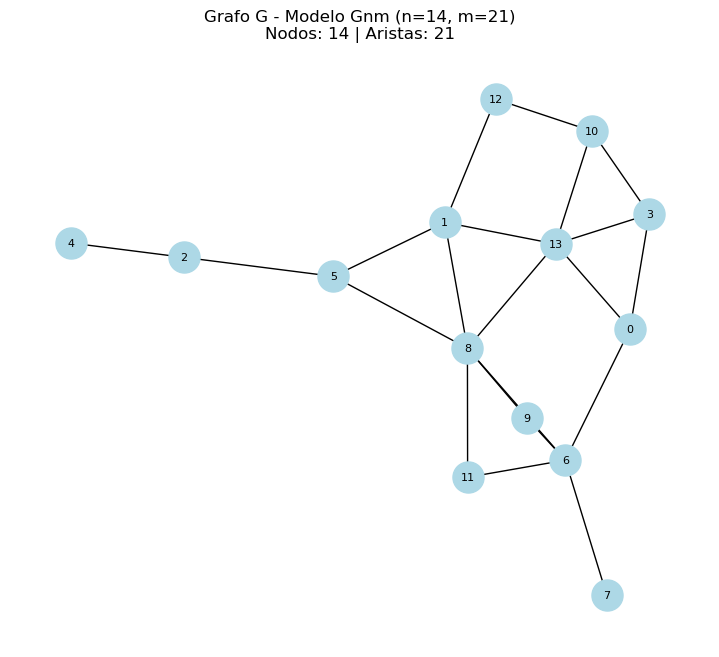

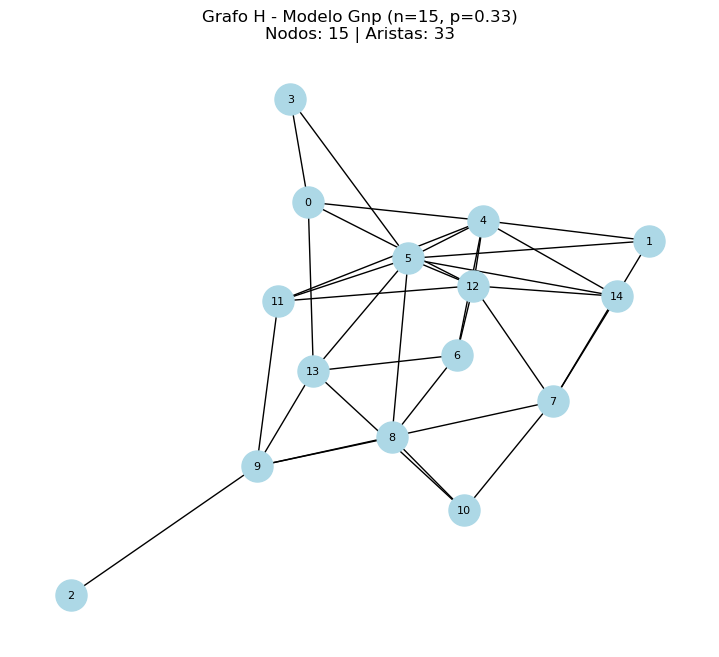

--- G ---
Nodos: 14
Aristas: 21
Grado promedio: 3.0

--- H ---
Nodos: 15
Aristas: 33
Grado promedio: 4.4



In [9]:
# Grafo G: modelo Gnm
n1 = random.randint(10, 15)
m1 = random.randint(n1, n1 + 8)
G = modelo_gnm(n1, m1)

# Grafo H: modelo Gnp
n2 = random.randint(10, 15)
p2 = random.uniform(0.2, 0.4)
H = modelo_gnp(n2, p2)

visualizar_grafo(G, f"Grafo G - Modelo Gnm (n={n1}, m={m1})")
visualizar_grafo(H, f"Grafo H - Modelo Gnp (n={n2}, p={p2:.2f})")

resumen(G, "G")
resumen(H, "H")

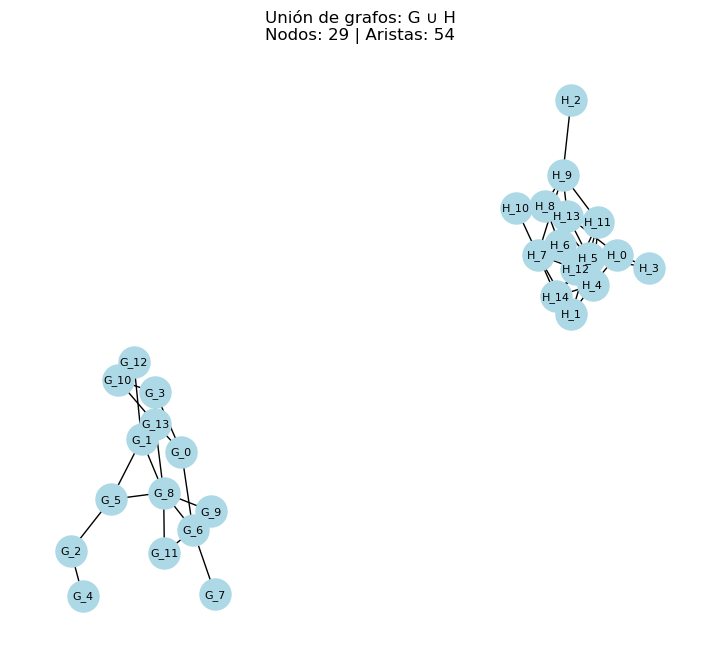

--- Unión G ∪ H ---
Nodos: 29
Aristas: 54
Grado promedio: 3.7241379310344827



In [10]:
U = union_grafos_scratch(G, H)

visualizar_grafo(U, "Unión de grafos: G ∪ H")
resumen(U, "Unión G ∪ H")

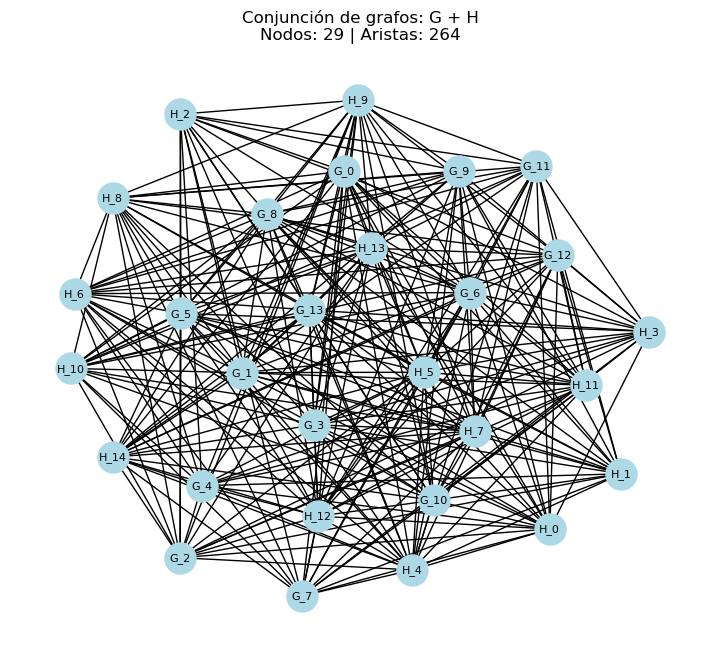

--- Conjunción G + H ---
Nodos: 29
Aristas: 264
Grado promedio: 18.20689655172414



In [11]:
J = conjuncion_grafos_scratch(G, H)

visualizar_grafo(J, "Conjunción de grafos: G + H")
resumen(J, "Conjunción G + H")

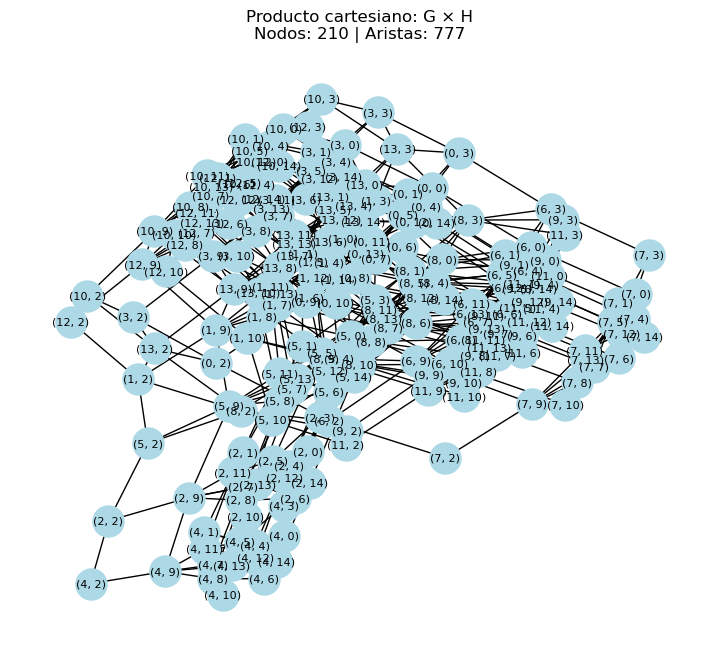

--- Producto cartesiano G × H ---
Nodos: 210
Aristas: 777
Grado promedio: 7.4



In [12]:
P = producto_cartesiano_scratch(G, H)

visualizar_grafo(P, "Producto cartesiano: G × H")
resumen(P, "Producto cartesiano G × H")